<a href="https://colab.research.google.com/github/ChAbid-773/World_Cities/blob/main/World_Cities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**World Cities**

In [1]:
import pandas as pd
import os

In [2]:
import kagglehub
path = kagglehub.dataset_download("okfn/world-cities")

Using Colab cache for faster access to the 'world-cities' dataset.


In [3]:
city=pd.read_csv(os.path.join(path,'world-cities.csv'))

In [4]:
city

,name,country,subcountry,geonameid
0,les Escaldes,Andorra,Escaldes-Engordany,3040051
1,Andorra la Vella,Andorra,Andorra la Vella,3041563
2,Umm al Qaywayn,United Arab Emirates,Umm al Qaywayn,290594
3,Ras al-Khaimah,United Arab Emirates,Raʼs al Khaymah,291074
4,Khawr Fakkān,United Arab Emirates,Ash Shāriqah,291696
...,...,...,...,...
23013,Bulawayo,Zimbabwe,Bulawayo,894701
23014,Bindura,Zimbabwe,Mashonaland Central,895061
23015,Beitbridge,Zimbabwe,Matabeleland South,895269
23016,Epworth,Zimbabwe,Harare,1085510


In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
coder=LabelEncoder()

In [7]:
city['name']=city['name'].astype(str)
city['name']=coder.fit_transform(city['name'])

In [8]:
city['country']=city['subcountry'].astype(str)
city['country']=coder.fit_transform(city['country'])

In [9]:
city['subcountry']=city['subcountry'].astype(str)
city['subcountry']=coder.fit_transform(city['subcountry'])

In [10]:
city

,name,country,subcountry,geonameid
0,21640,709,709,3040051
1,746,108,108,3041563
2,19839,2343,2343,290594
3,15738,1875,1875,291074
4,9305,163,163,291696
...,...,...,...,...
23013,3021,377,377,894701
23014,2425,1373,1373,895061
23015,2002,1380,1380,895269
23016,5752,871,871,1085510


In [11]:
x=city.drop(['country'],axis=1)
y=city['country']

In [12]:
x

,name,subcountry,geonameid
0,21640,709,3040051
1,746,108,3041563
2,19839,2343,290594
3,15738,1875,291074
4,9305,163,291696
...,...,...,...
23013,3021,377,894701
23014,2425,1373,895061
23015,2002,1380,895269
23016,5752,871,1085510


In [13]:
y

,country
0,709
1,108
2,2343
3,1875
4,163
...,...
23013,377
23014,1373
23015,1380
23016,871


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

#**Matplotlib Plot**

Text(0, 0.5, 'country')

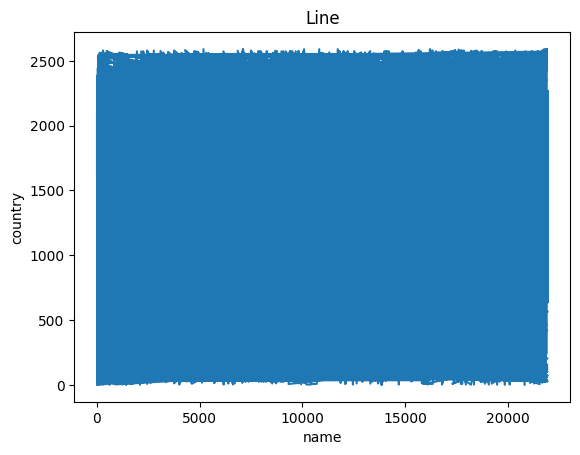

In [15]:
plt.plot(city['name'], city['country'])
plt.title('Line')
plt.xlabel('name')
plt.ylabel('country')

Text(0, 0.5, 'country')

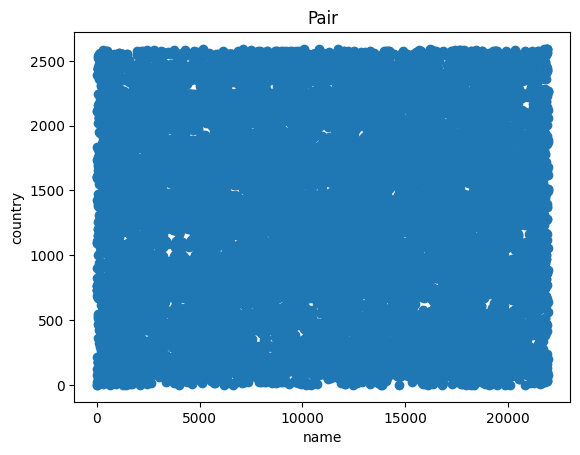

In [16]:
plt.scatter(city['name'], city['country'])
plt.title('Pair')
plt.xlabel('name')
plt.ylabel('country')

Text(0.5, 1.0, 'Histogram')

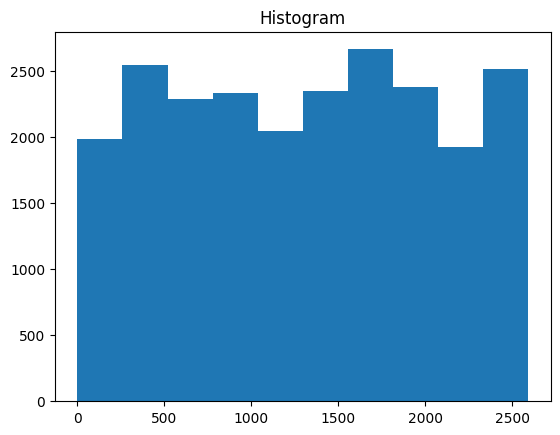

In [17]:
plt.hist(city['country'])
plt.title('Histogram')

Text(0.5, 1.0, 'Box')

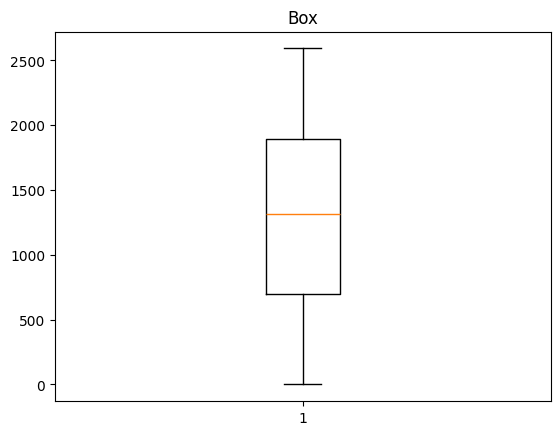

In [18]:
plt.boxplot(city['country'])
plt.title('Box')

Text(0.5, 1.0, 'Violin')

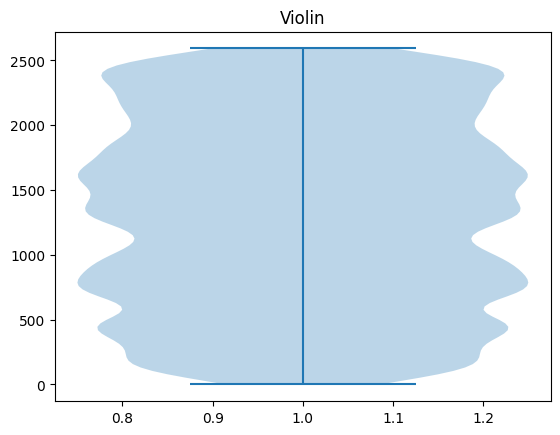

In [19]:
plt.violinplot(city['country'])
plt.title('Violin')

Text(0.5, 1.0, 'KDE')

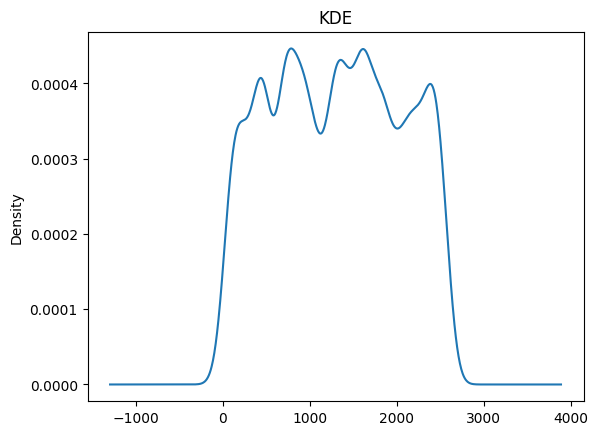

In [20]:
city['country'].plot(kind="kde")
plt.title('KDE')

#**Seaborn Plot**

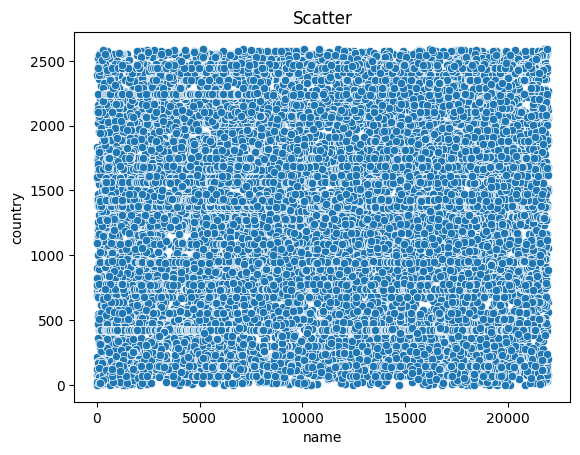

In [21]:
sns.scatterplot(x=city['name'], y=city['country'])
plt.title('Scatter')
plt.xlabel('name')
plt.ylabel('country')
plt.show()

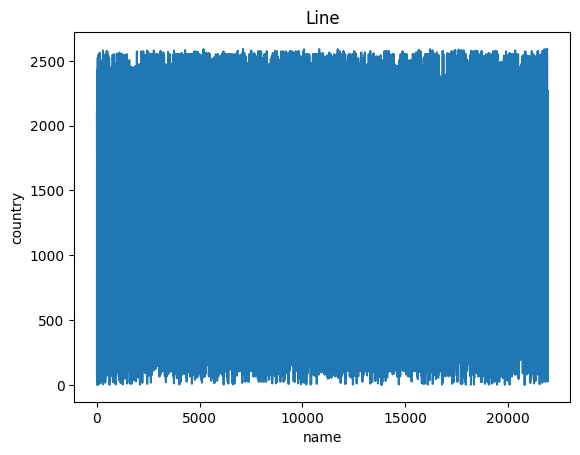

In [22]:
sns.lineplot(x=city['name'], y=city['country'])
plt.title('Line')
plt.xlabel('name')
plt.ylabel('country')
plt.show()

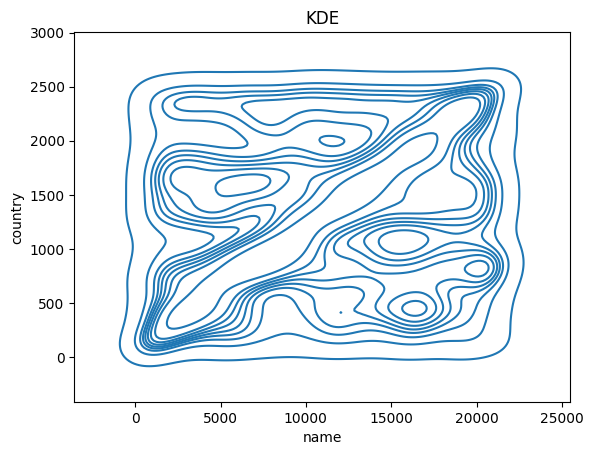

In [23]:
sns.kdeplot(x=city['name'], y=city['country'])
plt.title('KDE')
plt.xlabel('name')
plt.ylabel('country')
plt.show()

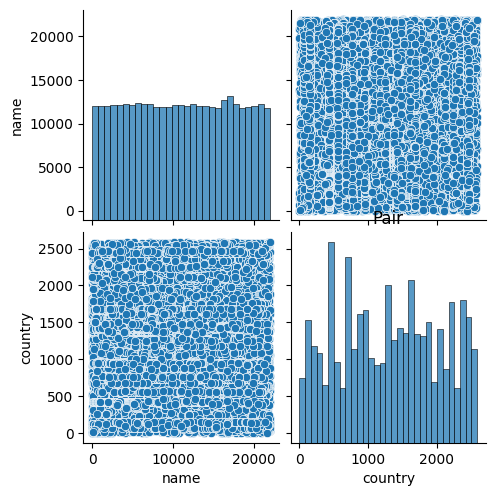

In [24]:
sns.pairplot(city[['name', 'country']])
plt.title('Pair')
plt.xlabel('name')
plt.ylabel('country')
plt.show()

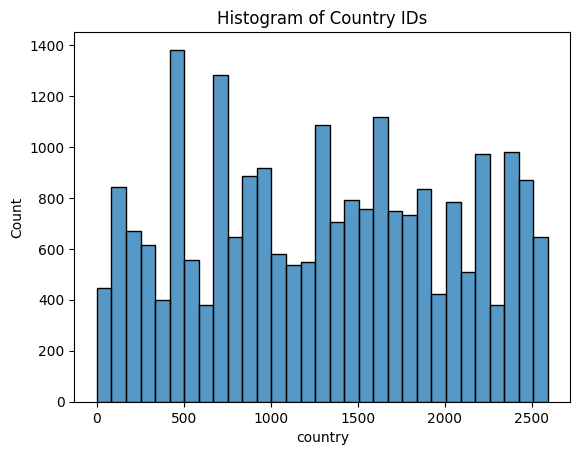

In [25]:
sns.histplot(city['country'])
plt.title('Histogram of Country IDs')
plt.show()

#**Testing and Training**

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [28]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18414 entries, 12153 to 21881
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        18414 non-null  int64
 1   subcountry  18414 non-null  int64
 2   geonameid   18414 non-null  int64
dtypes: int64(3)
memory usage: 575.4 KB


In [29]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4604 entries, 13947 to 19043
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        4604 non-null   int64
 1   subcountry  4604 non-null   int64
 2   geonameid   4604 non-null   int64
dtypes: int64(3)
memory usage: 143.9 KB


In [30]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 18414 entries, 12153 to 21881
Series name: country
Non-Null Count  Dtype
--------------  -----
18414 non-null  int64
dtypes: int64(1)
memory usage: 287.7 KB


In [31]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 4604 entries, 13947 to 19043
Series name: country
Non-Null Count  Dtype
--------------  -----
4604 non-null   int64
dtypes: int64(1)
memory usage: 71.9 KB


#**Linear Regression**

In [32]:
from sklearn.linear_model import LinearRegression
model1=LinearRegression()
model1.fit(x_train,y_train)
y_pred1=model1.predict(x_test)
print(y_pred1)

[2389. 1895. 2558. ... 2448. 1838.  316.]


In [33]:
df1=pd.DataFrame({'Actual':y_test,'Predicted':y_pred1}).reset_index(drop=True)
df1

,Actual,Predicted
0,2389,2389.0
1,1895,1895.0
2,2558,2558.0
3,214,214.0
4,2036,2036.0
...,...,...
4599,448,448.0
4600,424,424.0
4601,2448,2448.0
4602,1838,1838.0


#**K Means**

In [34]:
from sklearn.cluster import KMeans
model2=KMeans(n_clusters=3)
model2.fit(x_train,y_train)
y_pred2=model2.predict(x_test)
print(y_pred2)

[0 0 0 ... 1 1 1]


In [35]:
df2=pd.DataFrame({'Actual':y_test,'Predicted':y_pred2}).reset_index(drop=True)
df2

,Actual,Predicted
0,2389,0
1,1895,0
2,2558,0
3,214,0
4,2036,1
...,...,...
4599,448,0
4600,424,2
4601,2448,1
4602,1838,1


#**Decision Tree**

In [36]:
from sklearn.tree import DecisionTreeClassifier
model3=DecisionTreeClassifier()
model3.fit(x_train,y_train)
y_pred3=model3.predict(x_test)
print(y_pred3)

[2389 1894 2558 ... 2448 1838  316]


In [37]:
df3=pd.DataFrame({'Actual':y_test,'Predicted':y_pred3}).reset_index(drop=True)
df3

,Actual,Predicted
0,2389,2389
1,1895,1894
2,2558,2558
3,214,214
4,2036,2037
...,...,...
4599,448,448
4600,424,424
4601,2448,2448
4602,1838,1838
